In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import joblib

In [55]:
housing_original = pd.read_csv("housing.csv")

In [56]:
housing_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [57]:
housing_original.iloc[:, :6].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population
0,-122.23,37.88,41.0,880.0,129.0,322.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0


In [58]:
housing_original.iloc[:, 5:].head()

,population,households,median_income,median_house_value,ocean_proximity
0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,496.0,177.0,7.2574,352100.0,NEAR BAY
3,558.0,219.0,5.6431,341300.0,NEAR BAY
4,565.0,259.0,3.8462,342200.0,NEAR BAY


In [59]:
housing_original['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [60]:
housing = housing_original[housing_original['ocean_proximity'] !='ISLAND'] 
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
Name: count, dtype: int64

In [61]:
housing = pd.get_dummies(housing, columns = ['ocean_proximity'], dtype = int, prefix = 'dmy')

## Testar att skapa nya variabler alltså feature engeering - som hur många rum per hushåll, hur stor del av rummen som är sovrum och hur många personer per hushåll.
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

In [62]:
housing.iloc[[1, 200, 1000, 1850, 5000], 9:]

,dmy_<1H OCEAN,dmy_INLAND,dmy_NEAR BAY,dmy_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
1,0,0,1,0,6.238137,0.155797,2.109842
200,0,0,1,0,4.046948,0.249420,4.666667
1000,0,1,0,0,4.842031,0.207107,2.706629
1850,0,0,0,1,6.282110,0.175246,2.887615
5000,1,0,0,0,4.491736,0.221251,3.845041


In [63]:
train_full, test = train_test_split(housing, test_size=0.2, random_state=40) 
train, val = train_test_split(train_full, test_size=0.25, random_state=36)

In [64]:
train.info()

<class 'pandas.DataFrame'>
Index: 12381 entries, 12054 to 14298
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 12381 non-null  float64
 1   latitude                  12381 non-null  float64
 2   housing_median_age        12381 non-null  float64
 3   total_rooms               12381 non-null  float64
 4   total_bedrooms            12261 non-null  float64
 5   population                12381 non-null  float64
 6   households                12381 non-null  float64
 7   median_income             12381 non-null  float64
 8   median_house_value        12381 non-null  float64
 9   dmy_<1H OCEAN             12381 non-null  int64  
 10  dmy_INLAND                12381 non-null  int64  
 11  dmy_NEAR BAY              12381 non-null  int64  
 12  dmy_NEAR OCEAN            12381 non-null  int64  
 13  rooms_per_household       12381 non-null  float64
 14  bedrooms_per_room 

In [65]:
train = train.dropna()
train.info()

<class 'pandas.DataFrame'>
Index: 12261 entries, 12054 to 14298
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 12261 non-null  float64
 1   latitude                  12261 non-null  float64
 2   housing_median_age        12261 non-null  float64
 3   total_rooms               12261 non-null  float64
 4   total_bedrooms            12261 non-null  float64
 5   population                12261 non-null  float64
 6   households                12261 non-null  float64
 7   median_income             12261 non-null  float64
 8   median_house_value        12261 non-null  float64
 9   dmy_<1H OCEAN             12261 non-null  int64  
 10  dmy_INLAND                12261 non-null  int64  
 11  dmy_NEAR BAY              12261 non-null  int64  
 12  dmy_NEAR OCEAN            12261 non-null  int64  
 13  rooms_per_household       12261 non-null  float64
 14  bedrooms_per_room 

In [66]:
val = val.dropna()
test = test.dropna()

In [67]:
from sklearn.impute import SimpleImputer
imputer_demo_df = pd.DataFrame({
'A': [7, 4, 10],
'B': [2, np.nan, 5],
'C': [3, 6, 9]
}) 
print(imputer_demo_df)
imputer = SimpleImputer(strategy='mean') 
df_imputed = imputer.fit_transform(imputer_demo_df)
print(df_imputed)
print("Before imputation, type:", type(imputer_demo_df))
print("After imputation, type:", type(df_imputed))

    A    B  C
0   7  2.0  3
1   4  NaN  6
2  10  5.0  9
[[ 7.   2.   3. ]
 [ 4.   3.5  6. ]
 [10.   5.   9. ]]
Before imputation, type: <class 'pandas.DataFrame'>
After imputation, type: <class 'numpy.ndarray'>


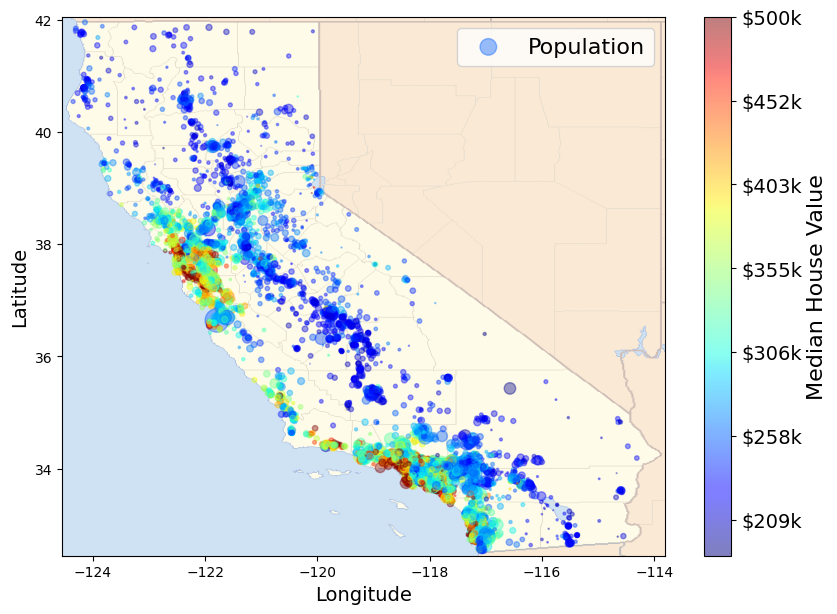

In [68]:
import matplotlib.image as mpimg
california_img=mpimg.imread('california.png') 
ax = train.plot(kind="scatter", x="longitude", y="latitude",
figsize=(10,7),
s=train['population']/100, label="Population",
c="median_house_value",
cmap=plt.get_cmap("jet"),
colorbar=False, alpha=0.4)
plt.imshow(california_img, extent=[-124.55,
-113.80, 32.45,
42.05], alpha=0.5,
cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)
prices = train["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values/prices.max())
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in
tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)
plt.legend(fontsize=16)

In [69]:
corr_matrix = train.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.689648
dmy_<1H OCEAN               0.253893
rooms_per_household         0.164550
dmy_NEAR BAY                0.159601
dmy_NEAR OCEAN              0.148101
total_rooms                 0.132945
housing_median_age          0.099810
households                  0.063797
total_bedrooms              0.048099
population                 -0.025675
population_per_household   -0.025743
longitude                  -0.043444
latitude                   -0.147407
bedrooms_per_room          -0.265840
dmy_INLAND                 -0.485680
Name: median_house_value, dtype: float64

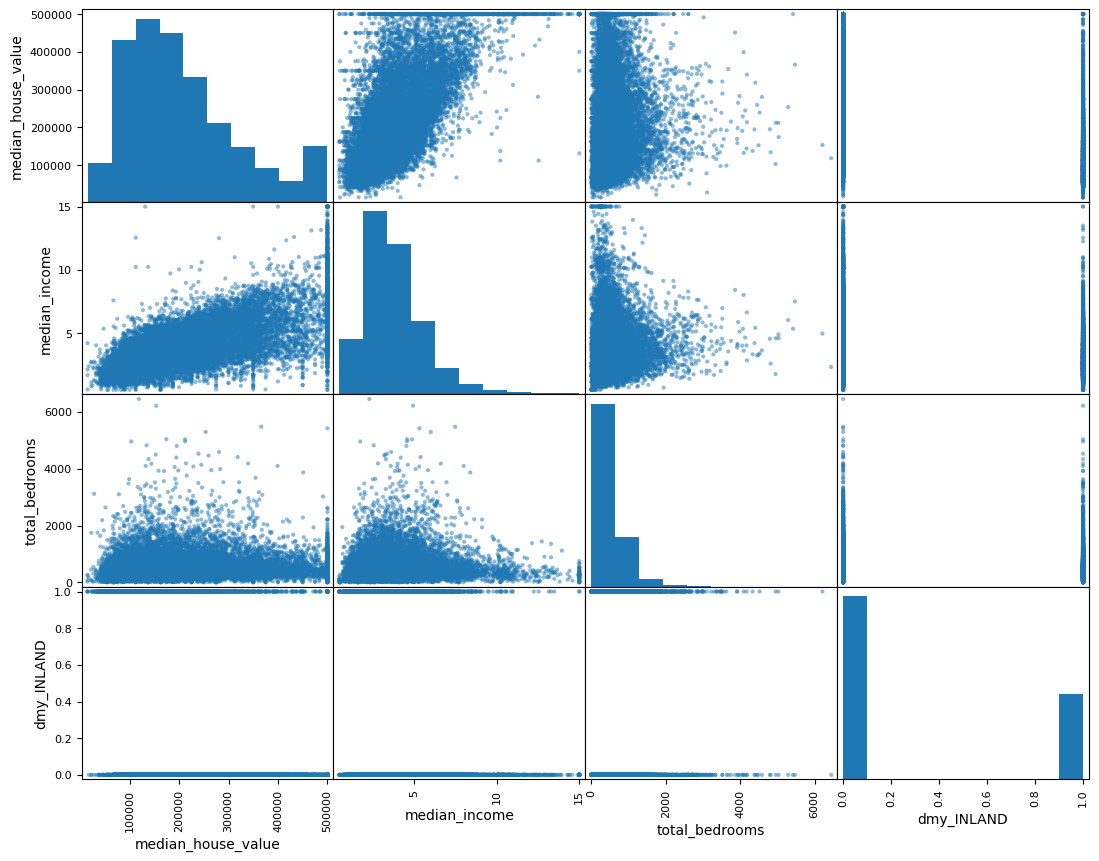

In [70]:
attributes = ["median_house_value", "median_income", "total_bedrooms", "dmy_INLAND"]
pd.plotting.scatter_matrix(housing[attributes], figsize=(13, 10))
plt.show()

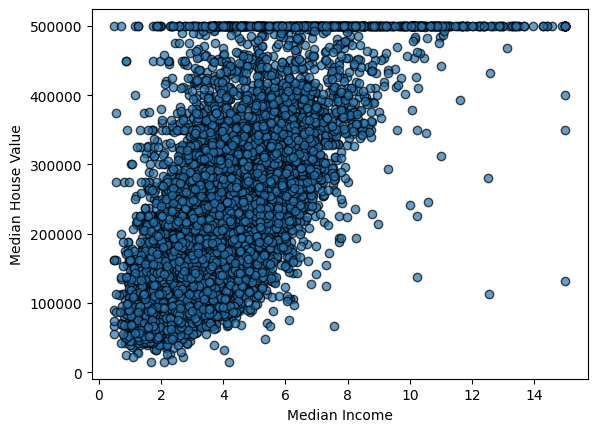

In [71]:
plt.scatter(train['median_income'], train['median_house_value'],
alpha=0.7, edgecolor='k')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

<Axes: xlabel='dmy_<1H OCEAN', ylabel='median_house_value'>

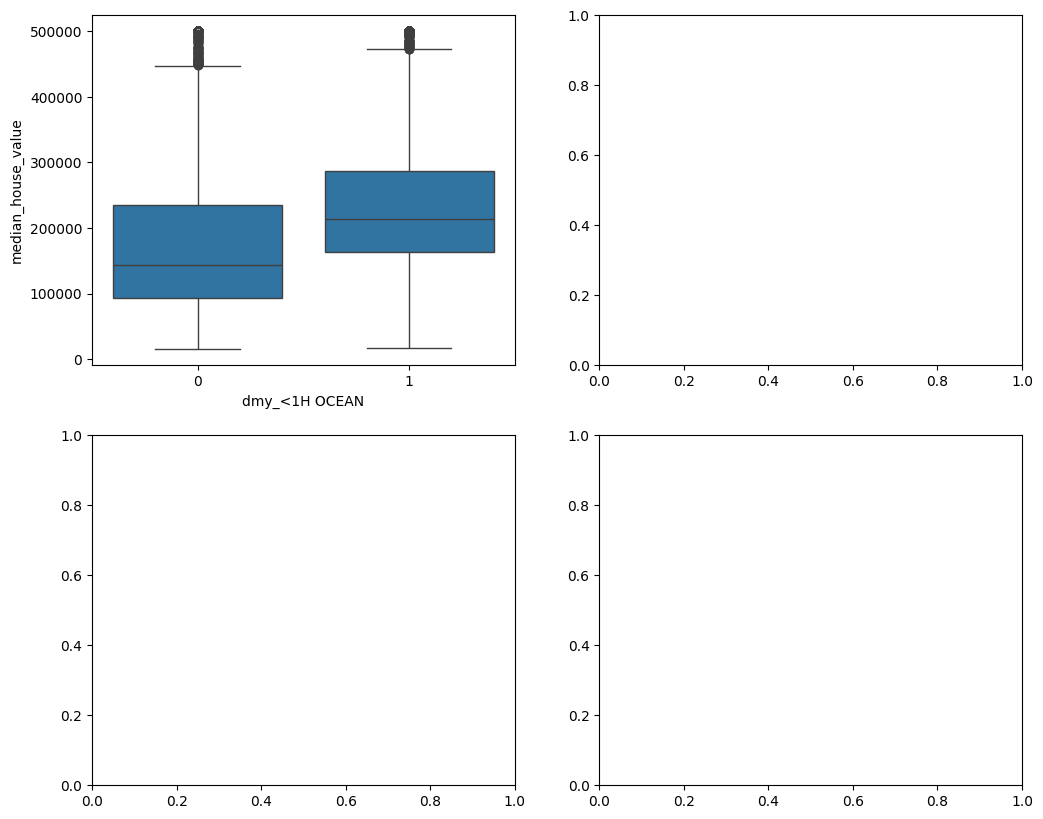

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(data=train, x='dmy_<1H OCEAN', y='median_house_value',
ax=axes[0, 0])

In [73]:
sns.boxplot(data=train, x='dmy_INLAND', y='median_house_value',
ax=axes[0, 1])
sns.boxplot(data=train, x='dmy_NEAR BAY', y='median_house_value',
ax=axes[1, 0])
sns.boxplot(data=train, x='dmy_NEAR OCEAN',
y='median_house_value', ax=axes[1, 1])

<Axes: xlabel='dmy_NEAR OCEAN', ylabel='median_house_value'>

In [74]:
X_train_full = train_full.drop(columns=['median_house_value']) 
y_train_full = train_full['median_house_value'] 
X_train, y_train = train.drop(columns=['median_house_value']), train['median_house_value']
X_val, y_val = val.drop(columns=['median_house_value']), val['median_house_value']
X_test, y_test = test.drop(columns=['median_house_value']), test['median_house_value']

In [75]:
print(X_train.shape)
print(y_train.shape)

(12261, 15)
(12261,)


In [76]:
from sklearn.linear_model import LinearRegression 
lin_reg = LinearRegression() 
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
import time 
from sklearn.ensemble import RandomForestRegressor

In [78]:
start_time = time.time() 
rf = RandomForestRegressor(random_state=42)
##TESTAR BYTA UT HYPERPAREMTRAR 
hyperparam_grid = {'n_estimators': [50, 100], 'max_depth': [10, 20, None]}
grid_search = GridSearchCV(rf, hyperparam_grid,

scoring='neg_root_mean_squared_error', cv=5) 
grid_search.fit(X_train, y_train) 
end_time = time.time()
execution_time = end_time - start_time
print(f"GridSearchCV fitting took {execution_time:.4f} seconds.")


GridSearchCV fitting took 86.4494 seconds.


In [79]:
print("Best Hyperparameters from GridSearchCV:",

grid_search.best_params_) 
pd.DataFrame(grid_search.cv_results_)

Best Hyperparameters from GridSearchCV: {'max_depth': None, 'n_estimators': 100}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.352172,0.012073,0.007054,0.000093,10,50,"{'max_depth': 10, 'n_estimators': 50}",-52560.895097,-54511.350487,-53358.199818,-53833.076863,-54313.905427,-53715.485538,702.291574,6
1,2.755248,0.047306,0.013587,0.000240,10,100,"{'max_depth': 10, 'n_estimators': 100}",-52152.014299,-54439.154026,-53211.369601,-53680.007278,-54038.449277,-53504.198896,787.987986,5
2,1.962337,0.006212,0.015613,0.000313,20,50,"{'max_depth': 20, 'n_estimators': 50}",-50896.626494,-52760.227022,-51374.275195,-51411.485432,-51877.567611,-51664.036351,629.903321,4
3,3.940448,0.012946,0.031060,0.000491,20,100,"{'max_depth': 20, 'n_estimators': 100}",-50470.502629,-52602.367314,-51189.097546,-51336.398053,-51438.396751,-51407.352458,686.932543,2
4,2.031400,0.004321,0.017076,0.000441,None,50,"{'max_depth': None, 'n_estimators': 50}",-50864.011532,-52794.367482,-51404.899052,-51322.909576,-51837.157879,-51644.669104,652.580019,3
5,4.062257,0.019435,0.033400,0.000666,None,100,"{'max_depth': None, 'n_estimators': 100}",-50417.999013,-52685.986428,-51232.379016,-51258.765916,-51397.720840,-51398.570243,730.222687,1


In [80]:
lr_pred_val = lin_reg.predict(X_val) 
rf_pred_val = grid_search.predict(X_val) 
print('RMSE Linear Regression:', root_mean_squared_error(y_val, lr_pred_val)) 
print('RMSE Random Forest Regression:', root_mean_squared_error(y_val, rf_pred_val))

RMSE Linear Regression: 69091.46653769973
RMSE Random Forest Regression: 50638.16663815037


In [81]:
print(np.mean(y_val)) 
print(root_mean_squared_error(y_val, rf_pred_val)/np.mean(y_val))

207517.1138589618
0.2440192314575385


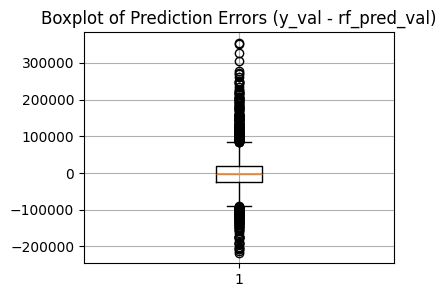

In [37]:
errors = y_val - rf_pred_val
plt.figure(figsize=(4, 3))
plt.boxplot(errors)
plt.title('Boxplot of Prediction Errors (y_val - rf_pred_val)')
plt.grid(True)

In [82]:
best_params = grid_search.best_params_
best_params

{'max_depth': None, 'n_estimators': 100}

In [83]:
best_rf = RandomForestRegressor(**best_params) 
best_rf.fit(X_train_full, y_train_full)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [84]:
best_rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [92]:
rf_pred_test = best_rf.predict(X_test)
rmse_test = root_mean_squared_error(y_test, rf_pred_test)
print('RMSE Random Forest on Test data:', rmse_test)
print(rmse_test/np.mean(y_test))

## Lägre RMSE :D

RMSE Random Forest on Test data: 49578.877594448066
0.2397958061447465


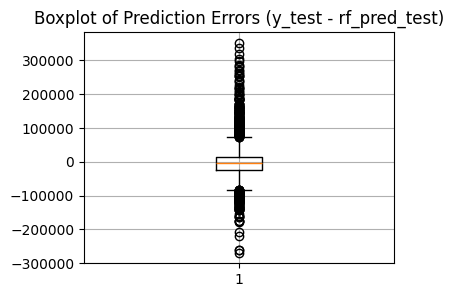

In [91]:
errors = y_test - rf_pred_test
plt.figure(figsize=(4, 3))
plt.boxplot(errors)
plt.title('Boxplot of Prediction Errors (y_test - rf_pred_test)')
plt.grid(True)

In [87]:
X_full = housing.drop(columns=['median_house_value'])
y_full = housing['median_house_value'] 
saved_model = RandomForestRegressor(**best_params)
saved_model.fit(X_full, y_full)
joblib.dump(saved_model, 'rf_saved_model.pkl')

['rf_saved_model.pkl']

In [89]:
new_districts = pd.DataFrame({
'longitude': [-118.30,
-117.85],
'latitude': [34.20, 33.90],
'housing_median_age': [35.0, 20.0],
'total_rooms': [880.0, 1200.0],
'total_bedrooms': [200.0, 300.0],
'population': [500.0, 750.0],
'households': [220.0, 280.0],
'median_income': [4.2, 5.1],
'dmy_<1H OCEAN': [0, 1],
'dmy_INLAND': [1, 0],
'dmy_NEAR BAY': [0, 0],
'dmy_NEAR OCEAN': [0, 0]
}) 

new_districts["rooms_per_household"] = new_districts["total_rooms"] / new_districts["households"]
new_districts["bedrooms_per_room"] = new_districts["total_bedrooms"] / new_districts["total_rooms"]
new_districts["population_per_household"] = new_districts["population"] / new_districts["households"]

predicted_values = saved_model.predict(new_districts) 
for i, value in enumerate(predicted_values, start=1):print(f"Predicted median house value for district {i}:${value:,.2f}")

Predicted median house value for district 1:$231,540.92
Predicted median house value for district 2:$218,739.01
